<a href="https://colab.research.google.com/github/riyoprayogi/MNIST/blob/rev/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"riyorizkyprayogi","key":"37e4606602e37425796b5a6de4f9d3cd"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
#Tesst API
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          13352        291                1  
nalisha/job-salary-prediction-dataset                               Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          15754        346                1  
mubashirsidiki/student-academic-performance-500-students            Student Academic Performance - 500 Students               6413  2026-04-07 14:23:47.547000           3531         73

In [4]:
!kaggle datasets download -d scolianni/mnistasjpg

Dataset URL: https://www.kaggle.com/datasets/scolianni/mnistasjpg
License(s): CC0-1.0
mnistasjpg.zip: Skipping, found more recently modified local copy (use --force to force download)


Padaa tahap ini ada folder yang tidak terpakai

In [6]:
import os, shutil

nested_path = "trainingSet/trainingSet"

if os.path.exists(nested_path):
    print("Fixing nested trainingSet...")

    for item in os.listdir(nested_path):
        src = os.path.join(nested_path, item)
        dst = os.path.join("trainingSet", item)

        # 🔥 kalau belum ada → move
        if not os.path.exists(dst):
            shutil.move(src, dst)
        else:
            print(f"Skip {item}, already exists")

    # hapus folder nested
    shutil.rmtree(nested_path)

Fixing nested trainingSet...
Skip 9, already exists
Skip 1, already exists
Skip 7, already exists
Skip 5, already exists
Skip 3, already exists
Skip 0, already exists
Skip 8, already exists
Skip 4, already exists
Skip 6, already exists
Skip 2, already exists


Cek

In [7]:
print(os.listdir("trainingSet"))

['9', '1', '7', '5', '3', '0', '8', '4', '6', '2']


# Extract dan Load Data

In [28]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28,28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_dataset = datasets.ImageFolder(root='trainingSet', transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

Cek

In [9]:
import os
print(os.listdir("trainingSet"))

['9', '1', '7', '5', '3', '0', '8', '4', '6', '2']


In [10]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(root='trainingSet', transform=transform)

print(train_dataset.classes)
print(len(train_dataset.classes))

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
10


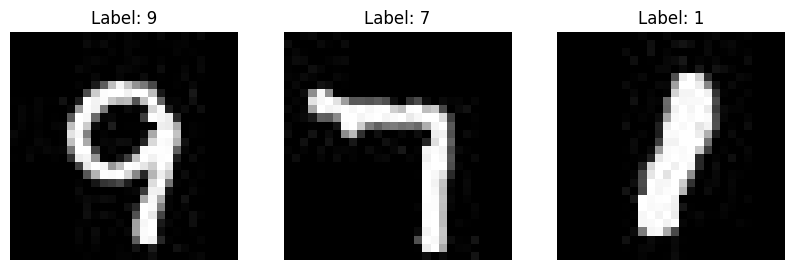

In [11]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i in range(3):
    idx = random.randint(0, len(train_dataset)-1)
    img, label = train_dataset[idx]

    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.show()

# Model

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64*7*7)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Test ada error sebelumnya

In [13]:
print(train_dataset.classes)
print(len(train_dataset.classes))

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
10


In [14]:
import os

print(os.listdir("trainingSet"))

['9', '1', '7', '5', '3', '0', '8', '4', '6', '2']


In [15]:
print(os.path.exists("trainingSet/trainingSet"))

False


# Training


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MNIST_CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Re-initialize train_dataset and test_dataset to ensure they reflect any previous directory cleanups.
train_dataset = datasets.ImageFolder(root='trainingSet', transform=transform)
test_dataset = datasets.ImageFolder(root='testSet', transform=transform)

# Re-create data loaders to ensure they use the latest (and correctly structured) datasets.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Dynamically get the number of classes from the dataset
num_classes = len(train_dataset.classes)

# Adjust the model's final layer if the number of output features doesn't match
if model.fc2.out_features != num_classes:
    print(f"Adjusting model's final layer from {model.fc2.out_features} to {num_classes} classes.")
    model.fc2 = nn.Linear(model.fc2.in_features, num_classes).to(device)
    # Reinitialize optimizer as model parameters have changed
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.1915
Epoch 2, Loss: 0.0509
Epoch 3, Loss: 0.0342
Epoch 4, Loss: 0.0260
Epoch 5, Loss: 0.0182


Cek

In [17]:
print("TRAIN:", train_dataset.class_to_idx)
print("TEST :", test_dataset.class_to_idx)

TRAIN: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}
TEST : {'testSet': 0}


In [18]:
print(len(train_dataset))
print(len(test_dataset))

42000
28000


# Train Accuracy

In [19]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Train Accuracy: {100 * correct / total:.2f}%")

Train Accuracy: 99.59%


# Confusin Matrix


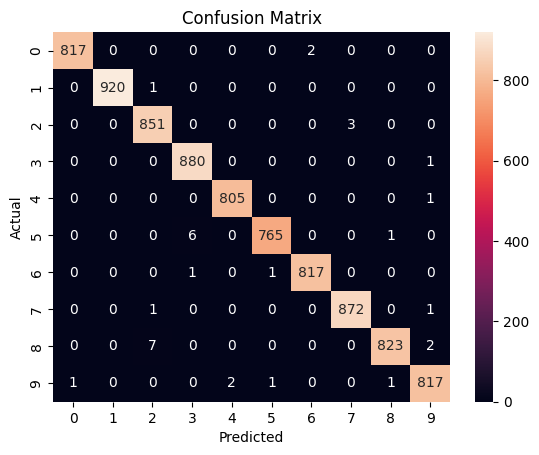

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
train_indices = set(train_dataset.indices)
val_indices   = set(val_dataset.indices)

print(len(train_indices.intersection(val_indices)))

0


In [32]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       819
           1       1.00      1.00      1.00       921
           2       0.99      1.00      0.99       854
           3       0.99      1.00      1.00       881
           4       1.00      1.00      1.00       806
           5       1.00      0.99      0.99       772
           6       1.00      1.00      1.00       819
           7       1.00      1.00      1.00       874
           8       1.00      0.99      0.99       832
           9       0.99      0.99      0.99       822

    accuracy                           1.00      8400
   macro avg       1.00      1.00      1.00      8400
weighted avg       1.00      1.00      1.00      8400



In [30]:
print(type(train_dataset))
print(type(val_dataset))

<class 'torch.utils.data.dataset.Subset'>
<class 'torch.utils.data.dataset.Subset'>


# Heatmap

In [33]:
gradients = []
activations = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

target_layer = model.conv2

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# Grad-cam dan Visualisasi

In [34]:
import torch
import numpy as np

def generate_gradcam(model, image, class_idx):
    gradients.clear()
    activations.clear()

    model.zero_grad()
    output = model(image)

    loss = output[0, class_idx]
    loss.backward()

    grad = gradients[-1]
    act  = activations[-1]

    # Global Average Pooling
    weights = grad.mean(dim=(2,3), keepdim=True)

    cam = (weights * act).sum(dim=1, keepdim=True)

    cam = torch.relu(cam)
    cam = cam.squeeze().detach().cpu().numpy()

    # 🔥 Normalize lebih stabil
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

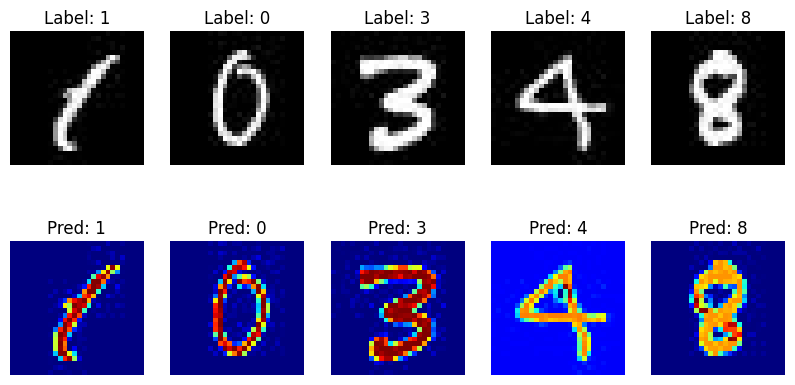

In [35]:
import matplotlib.pyplot as plt
import cv2

images, labels = next(iter(val_loader))

plt.figure(figsize=(10,5))

for i in range(5):
    img = images[i].unsqueeze(0).to(device)

    model.eval()
    output = model(img)
    pred_class = output.argmax(dim=1).item()

    cam = generate_gradcam(model, img, pred_class)
    cam = cv2.resize(cam, (28,28))

    # 🔥 enhance contrast
    cam = np.uint8(255 * cam)
    cam = cv2.applyColorMap(cam, cv2.COLORMAP_JET)

    original = images[i].squeeze().numpy()
    original = np.uint8(255 * (original - original.min()) / (original.max() - original.min()))

    overlay = cv2.addWeighted(original, 0.6, cam[:,:,0], 0.4, 0)

    plt.subplot(2,5,i+1)
    plt.imshow(original, cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(overlay, cmap='jet')
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

plt.show()

Berdasarkan visualisasi Grad-CAM, model CNN menunjukkan fokus pada bagian utama dari digit, seperti garis dan lengkungan yang membentuk angka. Hal ini menunjukkan bahwa model berhasil mengekstraksi fitur spasial yang relevan untuk proses klasifikasi.